# DATA 602 — Proposal EDA
## Dissolved Oxygen Forecasting, Patapsco River (Aquarium East Bottom)

Basic EDA to confirm the dataset can answer our research questions.

**Data source:** Maryland DNR, Eyes on the Bay.
https://eyesonthebay.dnr.maryland.gov/contmon/ContMon.cfm


## 1. Setup



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

CSV_PATH = 'Test_Station.csv'

raw = pd.read_csv(CSV_PATH)
print(f'{len(raw):,} rows x {raw.shape[1]} columns')
print()
print('Columns as downloaded:')
for c in raw.columns:
    print(f'  {c!r}')

17,664 rows x 13 columns

Columns as downloaded:
  'Sample_date'
  'Sample_Time'
  'DateTime'
  'Station'
  'Layer'
  'Salinity_ppt'
  'pH'
  'DO_mg/L'
  'DO_pctSat'
  'Turb_NTU'
  'Chl_ug/L'
  'BGA_RFU'
  'Temp_C'


### 2. Tidy the Columns

Eyes on the Bay already has one row per timestamp in wide format, so no pivoting is needed.

Rename the parameter columns to shorter names and create a proper timestamp.

`BGA_RFU` (blue-green algae) is only recorded at a few stations and is mostly empty, so we drop columns that are 100% null.


In [2]:
# Map the export's column names onto short names.
# Matching is on lowercase substrings so it survives small naming changes.
RENAME_RULES = [
    ('temp',      'WTEMP'),     # Temp_C
    ('salin',     'SALINITY'),  # Salinity_ppt
    ('pctsat',    'DOSAT'),     # DO_pctSat   (check BEFORE the plain 'do' rule)
    ('do_mg',     'DO'),        # DO_mg/L
    ('ph',        'PH'),
    ('turb',      'TURB'),      # Turb_NTU
    ('chl',       'CHLA'),      # chlorophyll
    ('bga',       'BGA'),
]

def short_name(col):
    c = col.strip().lower()
    for key, name in RENAME_RULES:
        if key in c:
            return name
    return col.strip()

df = raw.copy()
df.columns = [c.strip() for c in df.columns]
df = df.loc[:, [c for c in df.columns if c]]          # drop trailing empty column
df = df.rename(columns={c: short_name(c) for c in df.columns})

# Timestamp. The export gives both a combined DateTime and split date/time columns.
df['timestamp'] = pd.to_datetime(df['DateTime'].astype(str).str.strip(),
                                 format='mixed', dayfirst=False)
df = df.sort_values('timestamp').reset_index(drop=True)

# Drop any parameter column that is entirely empty (BGA at most stations).
CANDIDATES = ['WTEMP', 'SALINITY', 'DO', 'DOSAT', 'PH', 'TURB', 'CHLA', 'BGA']
features = [c for c in CANDIDATES if c in df.columns and df[c].notna().any()]
dropped   = [c for c in CANDIDATES if c in df.columns and c not in features]

print('Station:', df['Station'].str.strip().unique())
print('Layer:  ', df['Layer'].str.strip().unique(), '  (B = bottom, S = surface, BS = below surface)')
print()
print('Features kept   :', features)
print('Dropped (empty) :', dropped)

Station: <StringArray>
['Patapsco River  - Aquarium East Bottom']
Length: 1, dtype: str
Layer:   <StringArray>
['B']
Length: 1, dtype: str   (B = bottom, S = surface, BS = below surface)

Features kept   : ['WTEMP', 'SALINITY', 'DO', 'DOSAT', 'PH', 'TURB', 'CHLA']
Dropped (empty) : ['BGA']


## 3. Coverage check

Sampling is every 15 minutes, so 96 readings per day. This confirms we have a
continuous series with no missing timestamps, and gives the sample count for the proposal.

In [3]:
span_steps = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 900 + 1

print(f"Date range   : {df['timestamp'].min()}  to  {df['timestamp'].max()}")
print(f"Rows         : {len(df):,}")
print(f"Expected rows: {span_steps:,.0f}   (at one reading per 15 min)")
print(f"Completeness : {100*len(df)/span_steps:.2f}%")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")
print()
print('Interval between consecutive rows (minutes):')
print(df['timestamp'].diff().dt.total_seconds().div(60).value_counts().head().to_string())

Date range   : 2024-04-01 00:00:00  to  2024-10-01 23:45:00
Rows         : 17,664
Expected rows: 17,664   (at one reading per 15 min)
Completeness : 100.00%
Duplicate timestamps: 0

Interval between consecutive rows (minutes):
timestamp
15.0    17663


## 4. Feature inventory and target variable

The proposal must state each feature and whether it is continuous or categorical,
and must state the target variable and its nature. This is that table.

In [4]:
UNITS = {'WTEMP':'degC', 'SALINITY':'ppt', 'DO':'mg/L', 'DOSAT':'%',
         'PH':'unitless', 'TURB':'NTU', 'CHLA':'ug/L', 'BGA':'RFU'}

inventory = pd.DataFrame({
    'feature' : features,
    'units'   : [UNITS.get(f, '') for f in features],
    'dtype'   : [str(df[f].dtype) for f in features],
    'nature'  : 'continuous',
})
print(inventory.to_string(index=False))
print()
print('Also available, NOT continuous:')
print('  Station   - categorical')
print('  Layer     - categorical')
print('  timestamp - datetime; hour-of-day and day-of-year are cyclical,')
print('              to be encoded as sin/cos pairs rather than integers')
print()
print('TARGET VARIABLE: DO (dissolved oxygen, mg/L) shifted forward by the')
print('forecast horizon. Continuous -> regression.')
print('Secondary framing: DO < 2 mg/L (hypoxia). Binary -> classification.')
print()
print(df[features].describe().T.round(3).to_string())

 feature    units   dtype     nature
   WTEMP     degC float64 continuous
SALINITY      ppt float64 continuous
      DO     mg/L float64 continuous
   DOSAT        % float64 continuous
      PH unitless float64 continuous
    TURB      NTU float64 continuous
    CHLA     ug/L float64 continuous

Also available, NOT continuous:
  Station   - categorical
  Layer     - categorical
  timestamp - datetime; hour-of-day and day-of-year are cyclical,
              to be encoded as sin/cos pairs rather than integers

TARGET VARIABLE: DO (dissolved oxygen, mg/L) shifted forward by the
forecast horizon. Continuous -> regression.
Secondary framing: DO < 2 mg/L (hypoxia). Binary -> classification.

            count    mean     std    min     25%     50%     75%      max
WTEMP     17657.0  22.532   5.648  8.798  18.658  25.024  27.101   30.142
SALINITY  17652.0   6.160   2.258  2.210   4.950   5.990   6.950   13.750
DO        13689.0   2.746   2.810 -0.120   0.100   1.860   5.090   13.370
DOSAT    

## 5. Missing values

In [5]:
miss = pd.DataFrame({
    'n_missing': df[features].isna().sum(),
    'pct'      : (df[features].isna().mean()*100).round(3),
})
print(miss.to_string())

# Gaps come in contiguous blocks (sondes get pulled for calibration and foul up),
# so the block structure matters more than the overall percentage.
isna = df['DO'].isna().values
runs, cur = [], 0
for v in isna:
    if v: cur += 1
    elif cur: runs.append(cur); cur = 0
if cur: runs.append(cur)

print()
if runs:
    runs = np.array(runs)
    print(f'Contiguous gap blocks in DO : {len(runs)}')
    print(f'Longest gap                 : {runs.max()} rows ({runs.max()*15/60:.1f} hours)')
    print(f'Blocks <= 2h (interpolable) : {(runs <= 8).sum()}')
    print(f'Blocks  > 2h (exclude)      : {(runs >  8).sum()}')
else:
    print('No gaps in the DO series.')

          n_missing     pct
WTEMP             7   0.040
SALINITY         12   0.068
DO             3975  22.503
DOSAT          3969  22.469
PH                7   0.040
TURB           1047   5.927
CHLA             15   0.085

Contiguous gap blocks in DO : 221
Longest gap                 : 504 rows (126.0 hours)
Blocks <= 2h (interpolable) : 173
Blocks  > 2h (exclude)      : 48


## 6. Outliers

We screen against physically plausible ranges rather than a statistical rule such as
z-score. Real hypoxic events are statistical outliers and are exactly what we want to
keep, so a z-score filter would delete our signal.

In [6]:
PHYSICAL_RANGES = {
    'WTEMP':(-2, 40), 'SALINITY':(0, 40), 'DO':(0, 25), 'DOSAT':(0, 250),
    'PH':(3, 12), 'TURB':(0, 2000), 'CHLA':(0, 500),
}

rows = []
for f in features:
    if f not in PHYSICAL_RANGES:
        continue
    lo, hi = PHYSICAL_RANGES[f]
    rows.append({'feature': f, 'plausible_range': f'[{lo}, {hi}]',
                 'observed_min': df[f].min(), 'observed_max': df[f].max(),
                 'n_outside': int(((df[f] < lo) | (df[f] > hi)).sum())})
print(pd.DataFrame(rows).to_string(index=False))

# Blank out implausible values before computing correlations.
clean = df.copy()
for f in features:
    if f in PHYSICAL_RANGES:
        lo, hi = PHYSICAL_RANGES[f]
        clean.loc[(clean[f] < lo) | (clean[f] > hi), f] = np.nan

 feature plausible_range  observed_min  observed_max  n_outside
   WTEMP        [-2, 40]         8.798        30.142          0
SALINITY         [0, 40]         2.210        13.750          0
      DO         [0, 25]        -0.120        13.370       2769
   DOSAT        [0, 250]        -1.300       133.800       2790
      PH         [3, 12]         6.590         8.640          0
    TURB       [0, 2000]        -0.170       169.480         31
    CHLA        [0, 500]         0.250        74.880          0


## 7. Correlation among features

Two things we are looking for:

- **Strong feature-to-feature correlation is a problem, not a finding.** If two columns
  carry the same information the model cannot tell us which one matters. Expect DO and
  DO saturation to be highly correlated, since saturation is derived from concentration,
  temperature and salinity.
- **Pearson vs Spearman disagreement means the relationship is curved.** Oxygen
  solubility falls non-linearly with temperature, so that pair should differ.

In [7]:
pearson  = clean[features].corr(method='pearson')
spearman = clean[features].corr(method='spearman')

print('PEARSON'); print(pearson.round(3).to_string())
print(); print('SPEARMAN'); print(spearman.round(3).to_string())

print()
print('Pairs where |Pearson - Spearman| > 0.10  (non-linear relationship):')
found = False
for i, a in enumerate(features):
    for b in features[i+1:]:
        d = abs(pearson.loc[a,b] - spearman.loc[a,b])
        if d > 0.10:
            print(f'  {a} x {b}:  Pearson {pearson.loc[a,b]:+.3f}   '
                  f'Spearman {spearman.loc[a,b]:+.3f}   diff {d:.3f}')
            found = True
if not found:
    print('  none')

print()
print('Pairs with |Pearson| > 0.80  (collinearity to resolve):')
found = False
for i, a in enumerate(features):
    for b in features[i+1:]:
        if abs(pearson.loc[a,b]) > 0.80:
            print(f'  {a} x {b}:  r = {pearson.loc[a,b]:+.3f}')
            found = True
if not found:
    print('  none')

PEARSON
          WTEMP  SALINITY     DO  DOSAT     PH   TURB   CHLA
WTEMP     1.000     0.317 -0.271 -0.128  0.010  0.185 -0.214
SALINITY  0.317     1.000 -0.287 -0.199 -0.097  0.118 -0.588
DO       -0.271    -0.287  1.000  0.983  0.777 -0.265  0.335
DOSAT    -0.128    -0.199  0.983  1.000  0.842 -0.260  0.304
PH        0.010    -0.097  0.777  0.842  1.000 -0.052  0.229
TURB      0.185     0.118 -0.265 -0.260 -0.052  1.000  0.010
CHLA     -0.214    -0.588  0.335  0.304  0.229  0.010  1.000

SPEARMAN
          WTEMP  SALINITY     DO  DOSAT     PH   TURB   CHLA
WTEMP     1.000     0.278 -0.297 -0.179 -0.124  0.234 -0.162
SALINITY  0.278     1.000 -0.313 -0.247 -0.107  0.176 -0.674
DO       -0.297    -0.313  1.000  0.989  0.775 -0.545  0.289
DOSAT    -0.179    -0.247  0.989  1.000  0.819 -0.539  0.259
PH       -0.124    -0.107  0.775  0.819  1.000 -0.220  0.118
TURB      0.234     0.176 -0.545 -0.539 -0.220  1.000 -0.085
CHLA     -0.162    -0.674  0.289  0.259  0.118 -0.085  1.000

Pairs

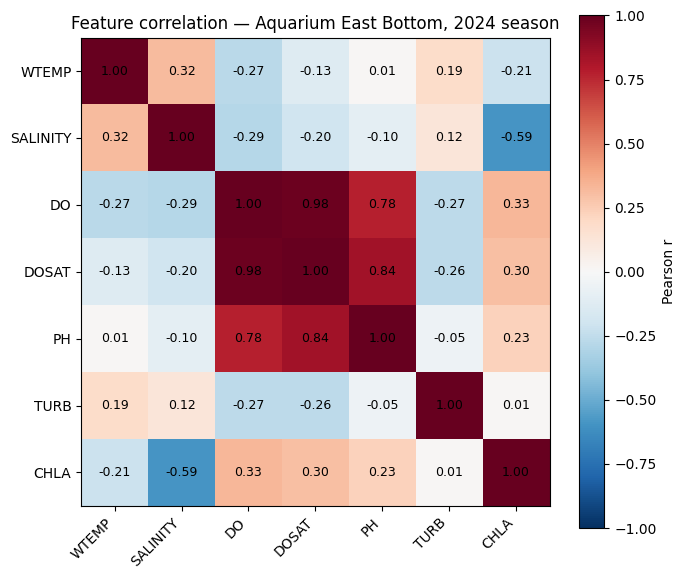

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pearson.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{pearson.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, label='Pearson r')
ax.set_title('Feature correlation — Aquarium East Bottom, 2024 season')
plt.tight_layout()
plt.show()

## 8. Correlation with the target

This is the correlation we *want* to be strong. We measure it at each forecast horizon.

The decay across horizons is itself a result worth reporting: it previews how far ahead
a model can hold before there is nothing left to learn.

In [9]:
HORIZONS_H = [1, 3, 6, 12, 24]
ROWS_PER_HOUR = 4

tab = {}
for h in HORIZONS_H:
    future_do = clean['DO'].shift(-h * ROWS_PER_HOUR)
    tab[f'{h}h'] = {f: clean[f].corr(future_do) for f in features}
target_corr = pd.DataFrame(tab)
print('Correlation of each feature with DO h hours ahead:')
print(target_corr.round(3).to_string())

Correlation of each feature with DO h hours ahead:
             1h     3h     6h    12h    24h
WTEMP    -0.273 -0.278 -0.287 -0.308 -0.359
SALINITY -0.281 -0.271 -0.250 -0.203 -0.096
DO        0.971  0.935  0.883  0.787  0.585
DOSAT     0.951  0.912  0.856  0.755  0.550
PH        0.754  0.721  0.671  0.576  0.386
TURB     -0.266 -0.260 -0.241 -0.213 -0.132
CHLA      0.317  0.307  0.300  0.286  0.212


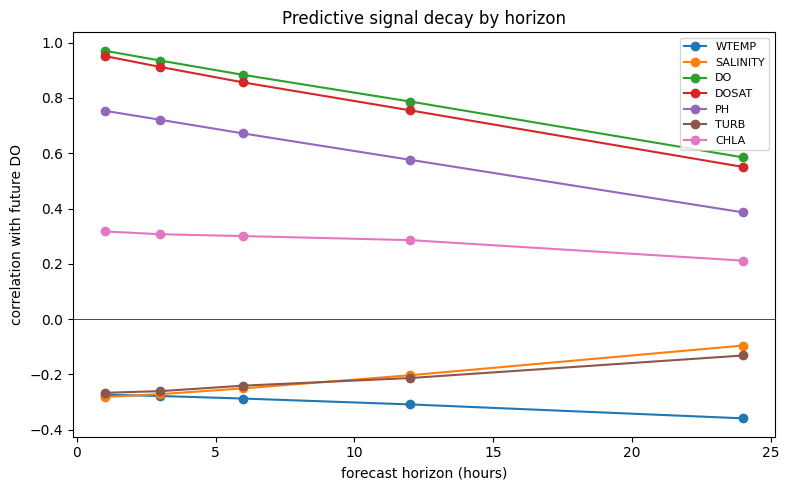

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for f in features:
    ax.plot(HORIZONS_H, target_corr.loc[f], marker='o', label=f)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('forecast horizon (hours)')
ax.set_ylabel('correlation with future DO')
ax.set_title('Predictive signal decay by horizon')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Persistence baseline

"DO in h hours will be whatever it is right now." Any model we build has to beat this,
so we need the number before we build anything.

Note this is **not** guaranteed to get worse as the horizon grows. These are tidal
waters, and the tide brings conditions back around.

In [11]:
print(f"DO standard deviation: {clean['DO'].std():.3f} mg/L")
print()
print(f"{'horizon':>8}  {'RMSE':>8}  {'MAE':>8}  {'-20% target':>12}  {'n':>8}")
for h in HORIZONS_H:
    pair = pd.concat([clean['DO'], clean['DO'].shift(-h*ROWS_PER_HOUR)], axis=1).dropna()
    err  = pair.iloc[:,1] - pair.iloc[:,0]
    rmse = np.sqrt((err**2).mean())
    print(f'{h:>6}h  {rmse:>8.3f}  {err.abs().mean():>8.3f}  {0.8*rmse:>12.3f}  {len(pair):>8,}')
print()
print('RMSE and MAE in mg/L. The -20% column is what our model must reach')
print('to claim a 20% improvement over persistence.')

DO standard deviation: 2.724 mg/L

 horizon      RMSE       MAE   -20% target         n
     1h     0.652     0.461         0.522    10,449
     3h     0.967     0.693         0.774    10,184
     6h     1.297     0.922         1.038     9,970
    12h     1.761     1.250         1.409     9,679
    24h     2.476     1.795         1.981     9,164

RMSE and MAE in mg/L. The -20% column is what our model must reach
to claim a 20% improvement over persistence.


## 10. Hypoxia occurrence

Confirms the classification target is viable, and that this station actually
experiences the phenomenon we are modelling.

In [12]:
do = clean['DO']
print(f'Observed minimum DO: {do.min():.2f} mg/L')
print()
for t in [1.0, 2.0, 3.0, 5.0]:
    n = int((do < t).sum())
    label = {2.0: '  <- hypoxia threshold',
             5.0: '  <- Bay open-water criterion'}.get(t, '')
    print(f'  DO < {t} mg/L : {n:6,} rows ({100*n/do.notna().sum():5.2f}%){label}')

hypoxic = (do < 2.0)
print()
print(f'Class balance for binary classification: {100*hypoxic.mean():.1f}% positive')

Observed minimum DO: 0.00 mg/L

  DO < 1.0 mg/L :  2,869 rows (26.27%)
  DO < 2.0 mg/L :  4,236 rows (38.79%)  <- hypoxia threshold
  DO < 3.0 mg/L :  5,490 rows (50.27%)
  DO < 5.0 mg/L :  7,385 rows (67.63%)  <- Bay open-water criterion

Class balance for binary classification: 24.0% positive


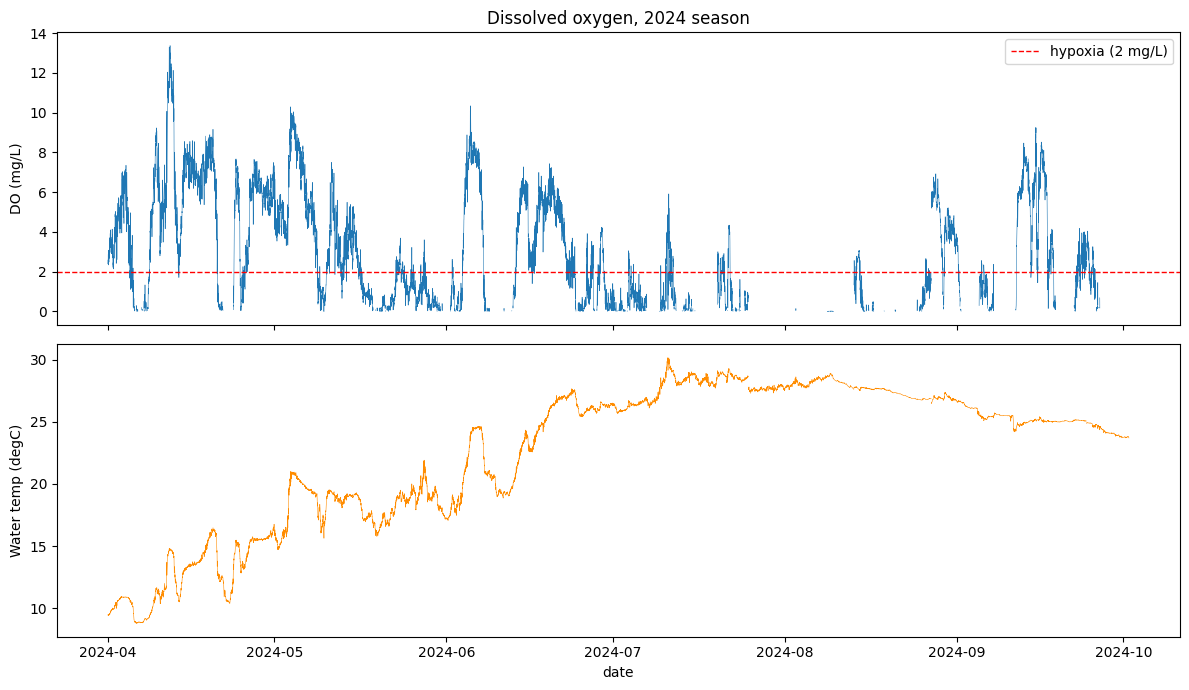

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(clean['timestamp'], clean['DO'], lw=0.4)
axes[0].axhline(2.0, color='red', ls='--', lw=1, label='hypoxia (2 mg/L)')
axes[0].set_ylabel('DO (mg/L)'); axes[0].legend(); axes[0].set_title('Dissolved oxygen, 2024 season')
axes[1].plot(clean['timestamp'], clean['WTEMP'], lw=0.4, color='darkorange')
axes[1].set_ylabel('Water temp (degC)'); axes[1].set_xlabel('date')
plt.tight_layout()
plt.show()